# Titanic Dataset - Exploratory Data Analysis (EDA)

### Objective:
Understand the dataset and find patterns that affect passenger survival.

### Tools Used:
- Python
- Pandas
- NumPy
- Seaborn
- Matplotlib

# Problem Understanding

### Business Problem:
We want to analyze which factors helped passengers survive the Titanic disaster.

### Target Variable:
- Survived (0 = No, 1 = Yes)

### Features:
- Age, Sex, Pclass, Fare, Embarked, etc.

### Goal:
- Find patterns
- Understand relationships
- Generate insights

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

# Import Data & Setup
Load dataset and check first few rows

In [94]:
df = pd.read_csv('/content/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Initial Data Inspection

Check:
- Shape of dataset
- Column names
- Data types
- Basic statistics

In [97]:
df.shape

(891, 12)

In [98]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [100]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Data Cleaning

Steps:
- Handle missing values
- Remove duplicates
- Fix data types

In [101]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [102]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin'], inplace=True)

/tmp/ipykernel_249/3046717843.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_249/3046717843.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [103]:
df.drop_duplicates(inplace=True)

# Univariate Analysis

Analyze one variable at a time.

### Numerical:
- Age
- Fare

### Categorical:
- Sex
- Survived

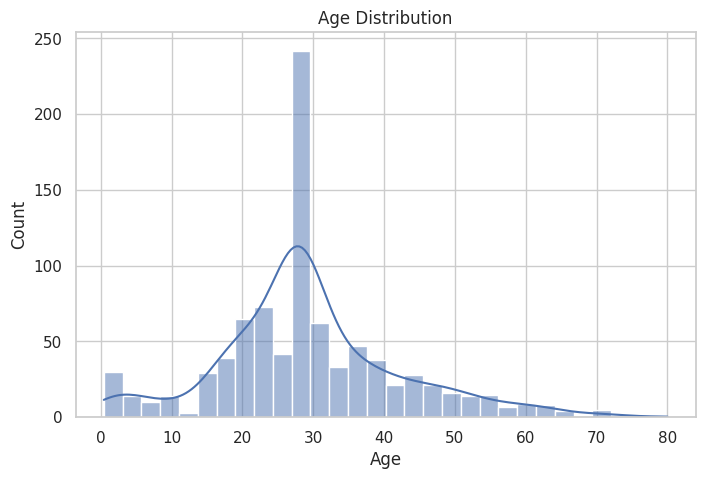

In [104]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

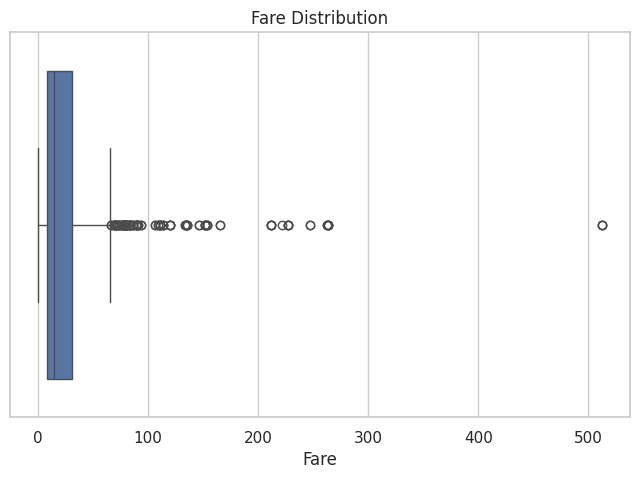

In [105]:
sns.boxplot(x=df['Fare'])
plt.title("Fare Distribution")
plt.show()

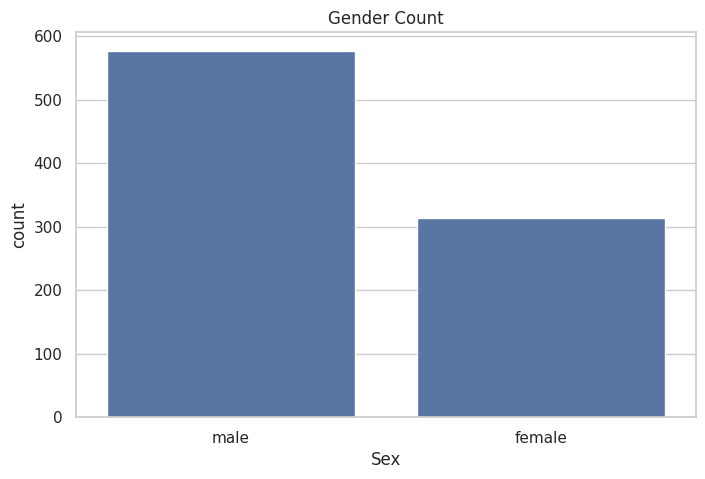

In [106]:
sns.countplot(x='Sex', data=df)
plt.title("Gender Count")
plt.show()

# Bivariate Analysis

Compare two variables to find relationships.

Examples:
- Age vs Fare
- Sex vs Survival

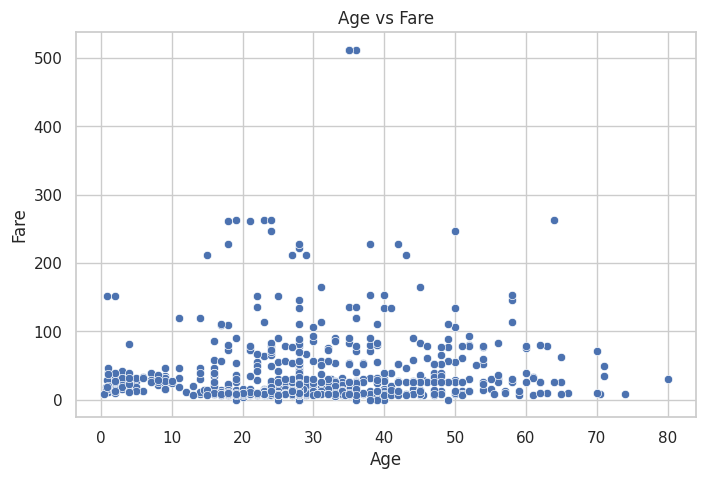

In [107]:
sns.scatterplot(x='Age', y='Fare', data=df)
plt.title("Age vs Fare")
plt.show()

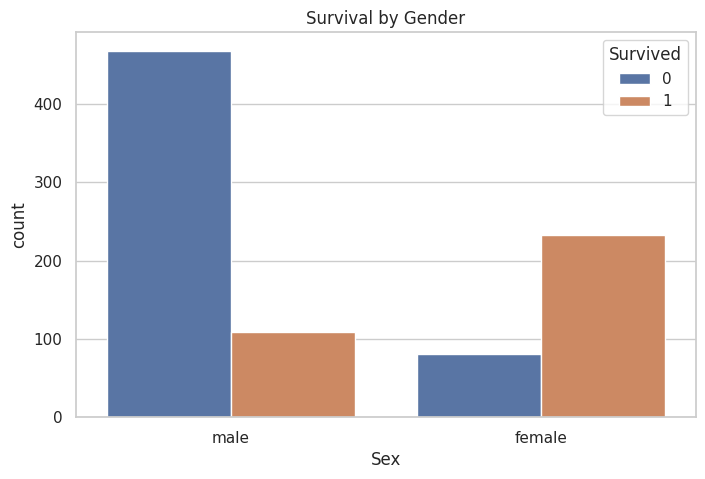

In [108]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

# Multivariate Analysis

Analyze multiple variables together.

Tools:
- Correlation matrix
- Heatmap

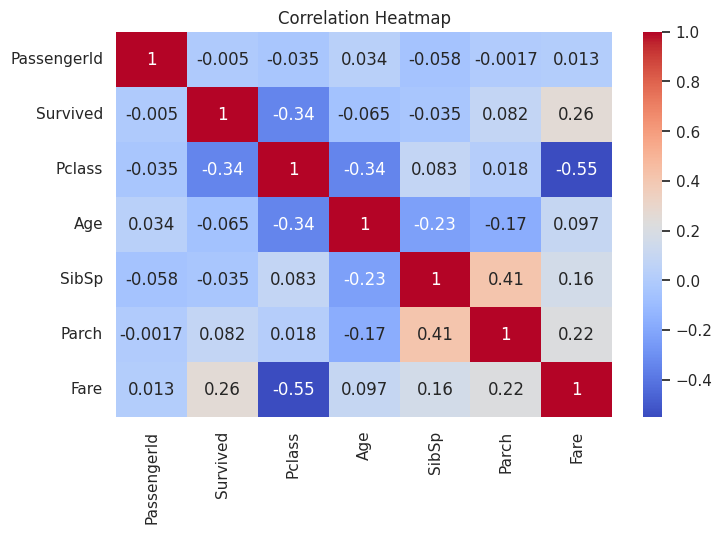

In [109]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Outlier Detection

Find extreme values in data using:
- Boxplots
- IQR method

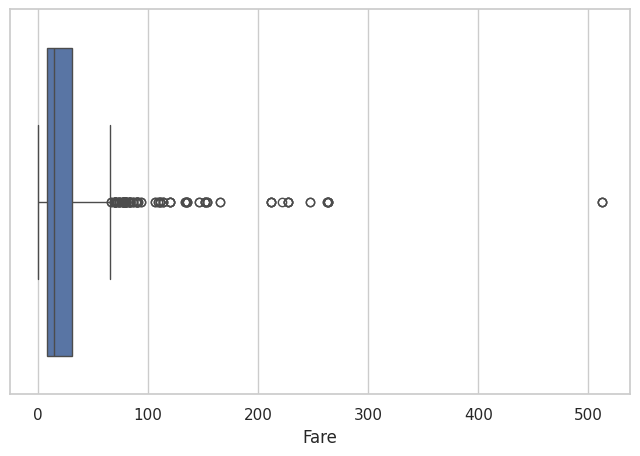

In [110]:
sns.boxplot(x=df['Fare'])
plt.show()

# Feature Engineering

Create new useful features:
- Family Size
- Fare per person

In [111]:
df['FamilySize'] = df['SibSp'] + df['Parch']
df['FarePerPerson'] = df['Fare'] / (df['FamilySize'] + 1)

# Feature Transformation

- Normalize data
- Convert categorical variables

In [112]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['Age','Fare']] = scaler.fit_transform(df[['Age','Fare']])

# Check Data Imbalance

Check if target variable is balanced or not

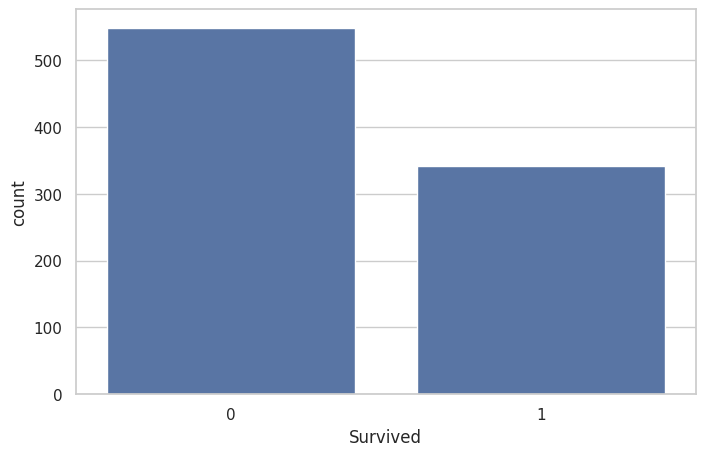

In [113]:
sns.countplot(x='Survived', data=df)
plt.show()

# Visualization & Insights

Understand patterns:
- Survival by class
- Survival by age

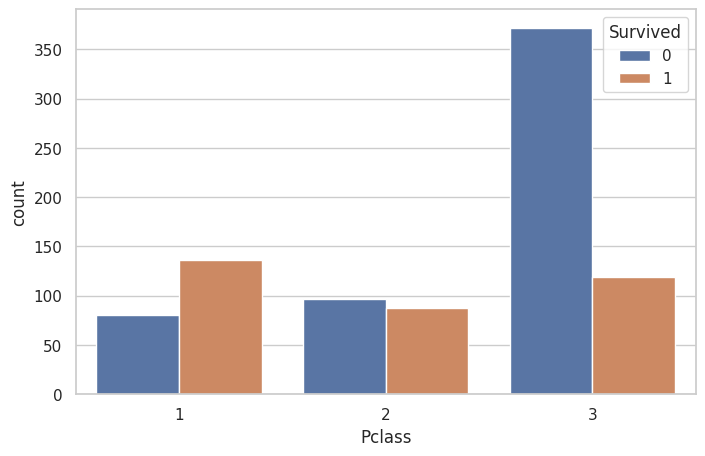

In [114]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.show()

# Conclusion / Insights

### Key Findings:

- Females survived more than males
- First class passengers had higher survival rate
- Fare is linked with survival
- Age has moderate impact
- Data needed cleaning before analysis

### Final Result:
Dataset is now clean and ready for:
- Machine Learning
- Dashboard (Power BI / Tableau)

In [120]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,FarePerPerson
0,1,0,3,"Braund, Mr. Owen Harris",male,0.271174,1,0,A/5 21171,0.014151,S,1,3.62500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0.472229,1,0,PC 17599,0.139136,C,1,35.64165
2,3,1,3,"Heikkinen, Miss. Laina",female,0.321438,0,0,STON/O2. 3101282,0.015469,S,0,7.92500
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.434531,1,0,113803,0.103644,S,1,26.55000
4,5,0,3,"Allen, Mr. William Henry",male,0.434531,0,0,373450,0.015713,S,0,8.05000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,0.334004,0,0,211536,0.025374,S,0,13.00000
887,888,1,1,"Graham, Miss. Margaret Edith",female,0.233476,0,0,112053,0.058556,S,0,30.00000
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,0.346569,1,2,W./C. 6607,0.045771,S,3,5.86250
889,890,1,1,"Behr, Mr. Karl Howell",male,0.321438,0,0,111369,0.058556,C,0,30.00000


In [121]:
df.to_csv('cleaned_titanic.csv', index=False)